In [7]:
# first cell just imports all the necessary packages, functions, and classes
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from analysis_classes import *
from analysis_funcs_and_consts import *
#set font to arial
plt.rcParams['font.family'] = 'Arial'
SOURCE_DATA_DIR = r"Z:\Adam-Lab-Shared\Data\Rotem_Kipper\Source_Data"




In [2]:
#auto reload
%load_ext autoreload
%autoreload 2
from analysis_classes import *
from analysis_funcs_and_consts import *

In [3]:
#just to get a dictionary with all cells
db_Analysis = DB_Analysis()
db_conditions = {(True, STRAIN) :['CKII', 'SST']} # get both CKII and SST cells
cells = db_Analysis.collect_cells(db_conditions, all=False)

# Fig 1b

In [5]:
CM_CONVERT = 160/190 #total 190 VirMen units is 160 cm
START_REWARD,END_REWARD = 128*CM_CONVERT, 148*CM_CONVERT
X_LIM = (0, 160)
ANTICIPATION = END_REWARD - START_REWARD

## Top

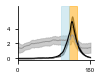

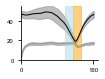

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_with_sem(
    filename,
    y_col,
    sem_col,
    y_lim,
    y_ticks,
    y_ticklabels,
    linewidth=1
):
    plot_df = pd.read_excel(SOURCE_DATA_DIR + filename)

    figsize_mm = (35, 25)
    figsize_inches = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
    plt.figure(figsize=figsize_inches)

    for condition, color in [
        ('before training', '0.6'),
        ('after training',  'k')
    ]:
        df = plot_df[plot_df['condition'] == condition].sort_values('end_of_bin')

        plt.plot(
            df['end_of_bin'],
            df[y_col],
            color=color,
            linewidth=linewidth,
            label=condition
        )

        plt.fill_between(
            df['end_of_bin'],
            df[y_col] - df[sem_col],
            df[y_col] + df[sem_col],
            color=color if y_col == 'lick_rate_mean' else 'grey',
            alpha=0.5,
            label='_nolegend_'
        )

    # reward zone
    plt.axvspan(START_REWARD, END_REWARD, alpha=0.5, color='orange')

    # anticipation zone
    plt.axvspan(
        START_REWARD - ANTICIPATION,
        START_REWARD - 0.2,
        alpha=0.5,
        color='lightblue'
    )

    plt.xlim(X_LIM[0], X_LIM[1])
    plt.ylim(*y_lim)

    plt.xticks([0, 150], [0, 160], fontsize=6)
    plt.yticks(y_ticks, y_ticklabels, fontsize=6)

    # styling
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('none')
    plt.savefig(SOURCE_DATA_DIR + filename.replace('.xlsx', '.svg'), bbox_inches='tight', dpi=300)
    plt.show()


plots = [
    {
        "filename": r'\1b_top.xlsx',
        "y_col": 'lick_rate_mean',
        "sem_col": 'lick_rate_sem',
        "y_lim": (-0.2, 7),
        "y_ticks": [0, 2, 4],
        "y_ticklabels": [0, 2, 4],
    },
    {
        "filename": r'\1b_bottom.xlsx',
        "y_col": 'speed_mean',
        "sem_col": 'speed_sem',
        "y_lim": (0, 550),
        "y_ticks": [0, 200, 400],
        "y_ticklabels": [0, 20, 40],
    }
]

for p in plots:
    plot_with_sem(**p)



# Fig 1d

In [9]:
cells_to_plot = ['RCK2_X_2_1','SRK1_X_24_1']
frames_to_plot = [42000,57000]
frames_after_frame_0 = [4200,5200]
for cell in cells:
    if cell.name in cells_to_plot:
        df=cell.exp.data
        df=cell.exp.bin_data_by_position(48,df)
        df = df.reset_index()
        TRACE_COL = data_utils.get_trace_col_prefix(df)
        trace = df[TRACE_COL+str(cell.cell_num)]
        trace = trace/np.nanstd(trace)
        trace = trace [frames_to_plot[0]:frames_to_plot[1]]
        sub_trace = delete_spikes_bittner_2017(cell)
        filtered_trace_bittner_sub = low_pass_filter_bittner2017(sub_trace, cutoff_freq=3, window_size=0.2, sampling_rate=cell.metadata[FRAME_RATE])
        filtered_trace_theta = butter_bandpass_filter(sub_trace, 4, 12, cell.metadata[FRAME_RATE], order=5)
        fig = make_subplots(
            rows=2 , cols=1,vertical_spacing=0.0,row_heights=[15,5],
            shared_xaxes=True)

        if cell.cell_type=='Pyr':
            cell_color='#d62728'
        elif cell.cell_type=='IN':
            cell_color=IN_COLOR
        else:
            cell_color='black'
        fig.add_scatter(name ='cell '+str(cell.cell_num), x=df.index, y=trace, line=dict(color = cell_color, width=1), showlegend=False ,row=1, col=1)

        fig.update_layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)')
        fig.update_layout(showlegend=False)
        ### add 3 scale bars:
        x_dist_to_scale_bar=len(trace)/50
        y_dist_to_scale_bar = max(trace)/3
        #add a vertical line at x=-1 with y = 5 SNR
        fig.add_shape(type="line",x0=-x_dist_to_scale_bar,x1=-x_dist_to_scale_bar,y0=0,y1=5,line=dict(color="black",width=2),yref="y")
        #add a vertical line at y=-max position value with x = 0 with time in seconds (multiply by num of ms per frame)
        fig.add_shape(type="line",x0=0,x1=cell.exp.metadata[FRAME_RATE]*2,y0=-y_dist_to_scale_bar,y1=-y_dist_to_scale_bar,line=dict(color="black",width=2),yref="y")

        fig.update_yaxes(visible=False, col=1)
        fig.update_xaxes(visible=False, col=1)    
        fig.update_layout(height=300, width=750)
        print(cell.name)
        fig.show()

SRK1_X_24_1


RCK2_X_2_1


# Fig 1e

In [10]:
reg_cells = [cell for cell in cells if cell.remapping==False and cell.session_num==0] # only non-remapping cells that are imaged for the first time

In [12]:
#Mean FR, violin plot, CKIIs vs. SSTs
mean_FRs={'CKII':[],'SST':[]}
for cell in reg_cells:
        mean_FR=calc_mean_fr_new(cell)
        if cell.strain=='CKII':
            mean_FRs['CKII'].append(mean_FR[0])
        elif cell.strain=='SST':
            mean_FRs['SST'].append(mean_FR[0])

CKII normality: ShapiroResult(statistic=0.8540817190978446, pvalue=8.009751380715427e-14)
SST normality: ShapiroResult(statistic=0.980747123372615, pvalue=0.011144165980812991)
RanksumsResult(statistic=-15.635703257908926, pvalue=4.158582294525453e-55)
n= 226 CKIIs &  187 SSTs
CKII mean FR: 4.92 SST mean FR: 18.23
CKII SEM: 0.3 SST SEM: 0.54


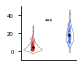

In [13]:
#shapiro-wilk test for normality
print('CKII normality:',stats.shapiro(mean_FRs['CKII']))
print('SST normality:',stats.shapiro(mean_FRs['SST']))
print(stats.ranksums(mean_FRs['CKII'], mean_FRs['SST']))
print('n=',len(mean_FRs['CKII']),'CKIIs & ' ,len(mean_FRs['SST']),'SSTs')
print('CKII mean FR:',round(np.mean(mean_FRs['CKII']),2), 'SST mean FR:',round(np.mean(mean_FRs['SST']),2))
print('CKII SEM:',round(stats.sem(mean_FRs['CKII']),2), 'SST SEM:',round(stats.sem(mean_FRs['SST']),2))

#second version
figsize_mm = (25, 25)
figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
fig,ax=plt.subplots(figsize=figsize_inch)
# Plot the violin
sns.violinplot(data=[mean_FRs['CKII'], mean_FRs['SST']],
               color='white', linewidth=0.5, width=0.5,
               zorder=0, alpha=1, inner=None, ax=ax)

# Set outline (violin body) to grey
for collection in ax.collections:
    collection.set_edgecolor('gray')

# Set the inner quartile lines to black
for line in ax.lines:
    line.set_color('black')
    line.set_linewidth(0.5)
# plt.ylabel('Mean FR [Hz]',fontsize=20)
#add all the individual data points as scatters on top of the violin plot with some jitter
random_jitter = np.random.normal(0, 0.02, size=len(mean_FRs['CKII']))
plt.scatter(np.zeros(len(mean_FRs['CKII']))+random_jitter, mean_FRs['CKII'], color=PYR_COLOR, s=2,alpha=0.3,edgecolors='none')
random_jitter = np.random.normal(0, 0.02, size=len(mean_FRs['SST']))
plt.scatter(np.ones(len(mean_FRs['SST']))+random_jitter, mean_FRs['SST'], color=IN_COLOR, s=2,alpha=0.3,edgecolors='none')
plt.scatter(0, np.mean(mean_FRs['CKII']), color='k', s=2, zorder=2)
plt.scatter(1, np.mean(mean_FRs['SST']), color='k', s=2, zorder=2)
plt.yticks([0, 20, 40], fontsize=SVG_TICKS); plt.xticks([])
# add significance stars
xlim = ax.get_xlim()
x_center = (xlim[0] + xlim[1]) / 2
y_max = max([max(mean_FRs['CKII']), max(mean_FRs['SST'])])
y, h, col = y_max + y_max/50, y_max/50, 'k'
plt.ylim([-10, y_max*1.2])
y_lim = ax.get_ylim()
# plt.plot([x1, x1, x2-0.1, x2-0.1], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text(x_center, y_lim[1]*0.6, "***", ha='center', va='bottom', color=col, fontsize=SVG_LABELS)
#remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
#remove background
fig.patch.set_facecolor('none')
plt.show()






# Fig 1f

In [14]:
#Burstiness, violin plot, CKIIs vs. SSTs
ISI_under_10={'CKII':[],'SST':[]}
for cell in reg_cells:
    # BI=cell.calc_burst_index() #mistake in this function, use corrected one below
    BI=cell.calc_burst_index_corrected()
    if cell.strain=='CKII':
        ISI_under_10['CKII'].append(BI[0])
    elif cell.strain=='SST':
        ISI_under_10['SST'].append(BI[0])
ISI_under_10['CKII']=[x*100 for x in ISI_under_10['CKII']]
ISI_under_10['SST']=[x*100 for x in ISI_under_10['SST']]

CKII normality: ShapiroResult(statistic=0.9593313513308626, pvalue=4.917395682067867e-06)
SST normality: ShapiroResult(statistic=0.8899934277083132, pvalue=1.6726672987334872e-10)
RanksumsResult(statistic=8.469615318783612, pvalue=2.4620476376401032e-17)
TtestResult(statistic=9.532633046422095, pvalue=1.3614641835048268e-19, df=411.0)
n= 226 CKIIs &  187 SSTs
CKII mean: 26.69 SST mean: 13.06
CKII SEM: 1.16 SST SEM: 0.71


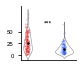

In [15]:
print('CKII normality:',stats.shapiro(ISI_under_10['CKII']))
print('SST normality:',stats.shapiro(ISI_under_10['SST']))
print(stats.ranksums(ISI_under_10['CKII'], ISI_under_10['SST']))
print(stats.ttest_ind(ISI_under_10['CKII'], ISI_under_10['SST']))
print('n=',len(ISI_under_10['CKII']),'CKIIs & ' ,len(ISI_under_10['SST']),'SSTs')
print('CKII mean:',round(np.mean(ISI_under_10['CKII']),2), 'SST mean:',round(np.mean(ISI_under_10['SST']),2))
print('CKII SEM:',round(stats.sem(ISI_under_10['CKII']),2), 'SST SEM:',round(stats.sem(ISI_under_10['SST']),2))

#second version
figsize_mm = (25, 25)
figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
fig,ax=plt.subplots(figsize=figsize_inch)
# Plot the violin
sns.violinplot(data=[ISI_under_10['CKII'], ISI_under_10['SST']],
               color='white', linewidth=0.5, width=0.5,
               zorder=0, alpha=1, inner=None, ax=ax)

# Set outline (violin body) to grey
for collection in ax.collections:
    collection.set_edgecolor('gray')

# Set the inner quartile lines to black
for line in ax.lines:
    line.set_color('black')
    line.set_linewidth(0.5)
#add all the individual data points as scatters on top of the violin plot with some jitter
random_jitter = np.random.normal(0, 0.03, size=len(ISI_under_10['CKII']))
plt.scatter(np.zeros(len(ISI_under_10['CKII']))+random_jitter, ISI_under_10['CKII'], color=PYR_COLOR, s=2,alpha=0.3,edgecolors='none')
random_jitter = np.random.normal(0, 0.03, size=len(ISI_under_10['SST']))
plt.scatter(np.ones(len(ISI_under_10['SST']))+random_jitter, ISI_under_10['SST'], color=IN_COLOR, s=2,alpha=0.3,edgecolors='none')
plt.scatter(0, np.mean(ISI_under_10['CKII']), color='k', s=2, zorder=2)
plt.scatter(1, np.mean(ISI_under_10['SST']), color='k', s=2, zorder=2)
plt.yticks([0, 25, 50], fontsize=SVG_TICKS); plt.xticks([])
# add significance stars
xlim = ax.get_xlim()
x_center = (xlim[0] + xlim[1]) / 2
y_max = max([max(ISI_under_10['CKII']), max(ISI_under_10['SST'])])
y, h, col = y_max + y_max/50, y_max/50, 'k'
plt.ylim([-10, y_max*1.2])
y_lim = ax.get_ylim()
# plt.plot([x1, x1, x2-0.1, x2-0.1], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text(x_center, y_lim[1]*0.6, "***", ha='center', va='bottom', color=col, fontsize=SVG_LABELS)
#remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
#remove background
fig.patch.set_facecolor('none')
plt.show()


# Fig 1g

In [16]:
CKII_ISIs=[]
SST_ISIs=[]
for cell in reg_cells:
    ISIs=cell.calc_isi()[0]
    if cell.strain=='CKII':
        CKII_ISIs.extend(ISIs)
    elif cell.strain=='SST':
        SST_ISIs.extend(ISIs)

#keep only the ISIs between 0 and 500 ms
CKII_ISIs=[x for x in CKII_ISIs if x<300]
SST_ISIs=[x for x in SST_ISIs if x<300]

CKII_ISI2=[x for x in CKII_ISIs if (x>80) & (x<300)]
SST_ISI2=[x for x in SST_ISIs if (x>80) & (x<300)]

            

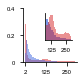

In [17]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# vectorized version
figsize_mm = (25, 25)
figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
fig, ax = plt.subplots(figsize=figsize_inch)
plt.hist(CKII_ISIs, bins=50, alpha=0.5, weights=np.ones(len(CKII_ISIs)) / len(CKII_ISIs), color=PYR_COLOR)
plt.hist(SST_ISIs, bins=50, alpha=0.5, weights=np.ones(len(SST_ISIs)) / len(SST_ISIs), color=IN_COLOR)
plt.xticks([2, 125, 250], [2, 125, 250], fontsize=SVG_TICKS)
plt.yticks([0, 0.2, 0.4], [0, 0.2, 0.4], fontsize=SVG_TICKS)
# remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add inset for the second histogram
ax_inset = inset_axes(plt.gca(), width="50%", height="50%", loc='upper right')  # Specify location and size of the inset
ax_inset.hist(SST_ISI2, bins=20, alpha=0.7, weights=np.ones(len(SST_ISI2)) / len(SST_ISIs), color=IN_COLOR)
ax_inset.hist(CKII_ISI2, bins=20, alpha=0.5, weights=np.ones(len(CKII_ISI2)) / len(CKII_ISIs), color=PYR_COLOR)
ax_inset.set_xticks([125, 250])
# hide y axis
ax_inset.yaxis.set_visible(False)
# remove the top and right spines
ax_inset.spines['top'].set_visible(False)
ax_inset.spines['right'].set_visible(False)
ax_inset.tick_params(axis='both', which='major', labelsize=6)
plt.show()



# Fig 1h

In [18]:
def calc_autocorrelogram(cell, max_lag=200, bin_size=2,bin_0_equals_1=True): #bin_0_equals_1=True means that the bin at 0 is normalized to 1, False means the spike itself is not counted
    # Convert spike times to milliseconds and ensure it's a NumPy array
    spike_times_ms = np.array(cell.spikes) / cell.metadata[FRAME_RATE] * 1000
    
    # Compute the differences in spike times
    diffs = spike_times_ms[:, None] - spike_times_ms
    if bin_0_equals_1:
        valid_diffs = diffs[(diffs > -max_lag) & (diffs < max_lag)].flatten()
    else:
        valid_diffs = diffs[(diffs > -max_lag) & (diffs < max_lag) &(diffs!=0)].flatten()
    
    # Calculate the histogram 
    bins = np.arange(-max_lag, max_lag + bin_size, bin_size)
    correlogram, _ = np.histogram(valid_diffs, bins=bins, weights=np.ones(len(valid_diffs))/len(spike_times_ms))

    return correlogram

def calc_autocorrelogram2(cell, max_lag=200,min_lag=4, bin_size=2,bin_0_equals_1=True): #bin_0_equals_1=True means that the bin at 0 is normalized to 1, False means the spike itself is not counted
    # Convert spike times to milliseconds and ensure it's a NumPy array
    spike_times_ms = np.array(cell.spikes) / cell.metadata[FRAME_RATE] * 1000
    
    # Compute the differences in spike times
    diffs = spike_times_ms[:, None] - spike_times_ms
    if bin_0_equals_1:
        valid_diffs = diffs[(abs(diffs) > min_lag) & (abs(diffs) < max_lag)].flatten()
    else:
        valid_diffs = diffs[(abs(diffs) > min_lag) & (abs(diffs) < max_lag) &(diffs!=0)].flatten()


    
    # Calculate the histogram 
    bins = np.arange(-max_lag, max_lag + bin_size, bin_size)
    correlogram, _ = np.histogram(valid_diffs, bins=bins, weights=np.ones(len(valid_diffs))/len(spike_times_ms))

    return correlogram


def calc_autocorrelogram_corrected(cell, max_lag=200, bin_size=2, bin_0_equals_1=True):
    fr = cell.metadata[FRAME_RATE]          # Hz (frames/s)
    spikes = np.asarray(cell.spikes, dtype=int)
    n = spikes.size
    if n < 2:
        return np.zeros(int(2*max_lag/bin_size) + 1), None

    # work in samples to avoid float binning asymmetries
    max_lag_samp = int(round(max_lag * fr / 1000))
    bin_samp     = max(1, int(round(bin_size * fr / 1000)))

    diffs = spikes[:, None] - spikes[None, :]   # in samples

    if bin_0_equals_1:
        valid = diffs[(diffs >= -max_lag_samp) & (diffs <= max_lag_samp)].ravel()
    else:
        valid = diffs[(diffs >= -max_lag_samp) & (diffs <= max_lag_samp) & (diffs != 0)].ravel()

    # symmetric bin edges in samples
    edges = np.arange(-max_lag_samp, max_lag_samp + bin_samp + 1, bin_samp)
    counts, _ = np.histogram(valid, bins=edges)

    # common normalization: per reference spike (optionally /bin width in seconds)
    counts = counts / n

    # return bin centers in ms for plotting
    centers_samp = (edges[:-1] + edges[1:]) / 2
    centers_ms = centers_samp * 1000 / fr
    return counts, centers_ms



In [117]:
#for each spike in the spike train, calculate the autocorrelogram by counting the number of spikes in each 2 ms bin for 125 ms before and after the spike. 
CKII_autocorrelogram=[]
SST_autocorrelogram=[]
count_less_than_100_spikes=0
max_lag=500
bin_size=4
for cell in tqdm(reg_cells):
    # autocorrelogram=calc_autocorrelogram_corrected(cell,max_lag=max_lag,bin_size=bin_size,bin_0_equals_1=False)
    # autocorrelogram=calc_autocorrelogram2(cell,max_lag=max_lag,min_lag=20,bin_size=bin_size,bin_0_equals_1=False)
    autocorrelogram=calc_autocorrelogram(cell,max_lag=500,bin_size=4,bin_0_equals_1=False) #original figure version?
    if cell.strain=='CKII':
        CKII_autocorrelogram.append(autocorrelogram)
    elif cell.strain=='SST':
        SST_autocorrelogram.append(autocorrelogram)

#remove the first and last bin from the autocorrelogram
CKII_autocorrelogram=[x[1:-1] for x in CKII_autocorrelogram]
SST_autocorrelogram=[x[1:-1] for x in SST_autocorrelogram]

            


100%|██████████| 413/413 [00:11<00:00, 36.61it/s] 


In [125]:
max_lag=500
bin_size=4

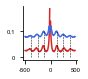

Number of CKII cells: 226
Number of SST cells: 187


In [130]:
CKII_autocorrelogram_trunc=[x[1:-1] for x in CKII_autocorrelogram]
SST_autocorrelogram_trunc=[x[1:-1] for x in SST_autocorrelogram]
#SVG format
figsize_mm = (25, 25)
figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
plt.figure(figsize=figsize_inch)
mean_autocorrelogram_ckii=np.mean(CKII_autocorrelogram_trunc,axis=0)
mean_autocorrelogram_sst=np.mean(SST_autocorrelogram_trunc,axis=0)
#turn the bins +-1 from 0 ms into nans for better visualization
mean_autocorrelogram_ckii[len(mean_autocorrelogram_ckii)//2 -1]=np.nan
mean_autocorrelogram_ckii[len(mean_autocorrelogram_ckii)//2 +1]=np.nan
mean_autocorrelogram_sst[len(mean_autocorrelogram_sst)//2 -1]=np.nan
mean_autocorrelogram_sst[len(mean_autocorrelogram_sst)//2 +1]=np.nan

plt.plot(mean_autocorrelogram_ckii,color=PYR_COLOR,linewidth=1.5)
plt.plot(mean_autocorrelogram_sst,color=IN_COLOR,linewidth=1.5)
# plt.ylabel('Probability',fontsize=20)
# plt.xlabel('Time [ms]',fontsize=20)
plt.xticks([0,125,250],[-500,0,500],fontsize=SVG_TICKS);plt.yticks([0,0.1],[0,0.1],fontsize=SVG_TICKS)
# plt.legend(['Pyr','SST'],fontsize=16)
# plt.ylim([0,0.15])
#add lines at -125/2, 125/2, 125+125/2, that end at the y value of the mean autocorrelogram at that time point
line_x = max_lag//bin_size
plt.xticks([0,line_x,line_x*2],[str(-max_lag),0,str(max_lag)],fontsize=SVG_TICKS);plt.yticks([0,0.1],[0,0.1],fontsize=SVG_TICKS)
plt.plot([line_x/2,line_x/2],[0,mean_autocorrelogram_sst[line_x//2]],color='k',linewidth=0.5,linestyle='--')
plt.plot([line_x+line_x/2,line_x+line_x/2],[0,mean_autocorrelogram_sst[line_x+line_x//2]],color='k',linewidth=0.5,linestyle='--')
#add same lines at half this x value
plt.plot([line_x/2+line_x/4,line_x/2+line_x/4],[0,mean_autocorrelogram_sst[line_x//2+line_x//4]],color='k',linewidth=0.5,linestyle='--')
plt.plot([line_x+line_x/4,line_x+line_x/4],[0,mean_autocorrelogram_sst[line_x+line_x//4]],color='k',linewidth=0.5,linestyle='--')
#add lines at 125 + 125*3/4
plt.plot([line_x+line_x*3/4,line_x+line_x*3/4],[0,mean_autocorrelogram_sst[line_x+line_x*3//4]],color='k',linewidth=0.5,linestyle='--')
plt.plot([line_x/2-line_x/4,line_x/2-line_x/4],[0,mean_autocorrelogram_sst[line_x//2-line_x//4]],color='k',linewidth=0.5,linestyle='--')
#remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

print('Number of CKII cells:',len(CKII_autocorrelogram))
print('Number of SST cells:',len(SST_autocorrelogram))

# Fig 1i

In [150]:
from scipy.signal import resample
from tqdm import tqdm
def calc_local_SNR_fast(cell, pre=3):
    spikes = np.asarray(cell.spikes, dtype=int)
    if spikes.size == 0:
        return np.nan

    trace = np.asarray(cell.trace, dtype=float)
    sub = np.asarray(cell.get_subthreshold_trace(), dtype=float)
    std = np.std(sub)
    if std == 0 or not np.isfinite(std):
        return np.nan

    # keep only spikes where s-pre is valid and s is valid
    spikes = spikes[(spikes >= pre) & (spikes < len(trace))]
    if spikes.size == 0:
        return np.nan

    # mini = min(trace[s-pre:s]) for each spike
    minis = np.array([trace[s-pre:s].min() for s in spikes], dtype=float)
    sbr = (trace[spikes] - minis) / std
    return np.nanmean(sbr)


CKII_list = []
SST_list  = []
CKII_dict = {}
SST_dict  = {}
for cell in tqdm(reg_cells):
    window_in_ms = 50  # total window size in ms
    fr = cell.metadata[FRAME_RATE]
    window_in_frames = int(round(fr * window_in_ms / 1000))
    trace = np.asarray(cell.trace, dtype=float)
    spikes = np.asarray(cell.spikes, dtype=int)

    if spikes.size < 1:
        continue

    # make sure sorted
    spikes = np.sort(spikes)

    # distance to previous and next spike
    prev_dt = np.r_[np.inf, np.diff(spikes)]
    next_dt = np.r_[np.diff(spikes), np.inf]

    # isolate spikes: far enough from neighbors on BOTH sides
    isolated = (prev_dt > window_in_frames) & (next_dt > window_in_frames)

    # also require window fits in trace
    trace = np.asarray(cell.trace, dtype=float)
    in_bounds = (spikes - window_in_frames >= 0) & (spikes + window_in_frames <= len(trace))

    valid_spikes = spikes[isolated & in_bounds]

    for spike in valid_spikes:
        vec = trace[spike - window_in_frames : spike + window_in_frames]
        norm_vec = normalize(vec)

        if len(norm_vec) != 50:
            norm_vec = resample(norm_vec, 50) # to include n=13 1000 Hz cells
            vec = resample(vec, 50)
        if cell.strain == 'CKII':
            CKII_list.append(norm_vec)
            CKII_dict[cell] = vec
        elif cell.strain == 'SST':
            SST_list.append(norm_vec)
            SST_dict[cell] = vec


CKII_shape = np.vstack(CKII_list) if len(CKII_list) else np.zeros((0, 100))
SST_shape  = np.vstack(SST_list)  if len(SST_list)  else np.zeros((0, 100))




100%|██████████| 413/413 [00:01<00:00, 347.57it/s]


Number of spikes used for CKII spike shape: 47098
Number of spikes used for SST spike shape: 75027
Number of CKII cells used: 226
Number of SST cells used: 187


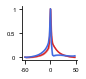

In [80]:
#print number of spikes used for each strain
print('Number of spikes used for CKII spike shape:', CKII_shape.shape[0])
print('Number of spikes used for SST spike shape:', SST_shape.shape[0])
#print number of cells used for each strain
num_CKII_cells = len(set([cell.name for cell in reg_cells if cell.strain == 'CKII' and len(cell.spikes) > 0]))
num_SST_cells = len(set([cell.name for cell in reg_cells if cell.strain == 'SST' and len(cell.spikes) > 0]))
print('Number of CKII cells used:', num_CKII_cells)
print('Number of SST cells used:', num_SST_cells)
#plot spike shapes and fill between the STD
figsize_mm = (25, 25)
figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
fig,ax=plt.subplots(figsize=figsize_inch)
mean_spike_shape_ckii=np.mean(CKII_shape,axis=0)
mean_spike_shape_sst=np.mean(SST_shape,axis=0)
sem_spike_shape_ckii=stats.sem(CKII_shape,axis=0)
sem_spike_shape_sst=stats.sem(SST_shape,axis=0)
#normalize the spike shapes between 0 and 1
mean_spike_shape_ckii=(mean_spike_shape_ckii-np.min(mean_spike_shape_ckii))/(np.max(mean_spike_shape_ckii)-np.min(mean_spike_shape_ckii))
mean_spike_shape_sst=(mean_spike_shape_sst-np.min(mean_spike_shape_sst))/(np.max(mean_spike_shape_sst)-np.min(mean_spike_shape_sst))
plt.plot(mean_spike_shape_ckii,color=PYR_COLOR,linewidth=1.5)
plt.plot(mean_spike_shape_sst,color=IN_COLOR,linewidth=1.5)
plt.fill_between(range(len(mean_spike_shape_ckii)), mean_spike_shape_ckii - sem_spike_shape_ckii, mean_spike_shape_ckii + sem_spike_shape_ckii, color=PYR_COLOR, alpha=0.3)
plt.fill_between(range(len(mean_spike_shape_sst)), mean_spike_shape_sst - sem_spike_shape_sst, mean_spike_shape_sst + sem_spike_shape_sst, color=IN_COLOR, alpha=0.3)

plt.yticks([0,0.5,1],[0,0.5,1],fontsize=SVG_TICKS);plt.xticks([0,25,50],['-50','0','50'],fontsize=SVG_TICKS)
#remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()


# Fig 1j

In [153]:
CKII_PSDs=[]
SST_PSDs=[]
CKII_PSDs_dict={}
SST_PSDs_dict={}
for cell in tqdm(reg_cells):
    psds,freqs=cell.get_power_spectrum()
    #keep only the frequencies between 2 and 20 Hz
    psds=psds[(freqs>=2) & (freqs<=20)]
    freqs=freqs[(freqs>=2) & (freqs<=20)]
    #bin the frequncies into 0.1 Hz bins, and average the power in each bin
    binned_psds=[]
    binned_freqs=[]
    for i in np.arange(2,20,0.1):
        binned_psds.append(np.mean(psds[(freqs>=i) & (freqs<=i+0.1)]))
        binned_freqs.append(i)
    psds=binned_psds
    #db scale
    freqs=binned_freqs
    if cell.strain=='CKII':
        CKII_PSDs.append(psds)
        CKII_PSDs_dict[cell]=psds
    elif cell.strain=='SST':
        SST_PSDs.append(psds)
        SST_PSDs_dict[cell]=psds
        

100%|██████████| 413/413 [00:24<00:00, 16.67it/s]


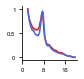

Number of CKII cells for PSD: 226
Number of SST cells for PSD: 187


In [145]:
#plot the power spectra and fill between the STD
figsize_mm = (25, 25)
figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
fig,ax=plt.subplots(figsize=figsize_inch)
mean_PSD_ckii=np.nanmean(CKII_PSDs,axis=0)
mean_PSD_sst=np.nanmean(SST_PSDs,axis=0)
mean_PSD_ckii=normalize(mean_PSD_ckii)
mean_PSD_sst=normalize(mean_PSD_sst)
sem_PSD_ckii=stats.sem(CKII_PSDs,axis=0,nan_policy='omit')
sem_PSD_sst=stats.sem(SST_PSDs,axis=0,nan_policy='omit')
plt.plot(freqs,mean_PSD_ckii,color=PYR_COLOR,linewidth=1.5)
plt.plot(freqs,mean_PSD_sst,color=IN_COLOR,linewidth=1.5)
plt.yticks([0,0.5,1],[0,0.5,1],fontsize=SVG_TICKS)
plt.yticks(fontsize=SVG_TICKS)
plt.xticks([0,8,16],[0,8,16],fontsize=SVG_TICKS)
#remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()
print('Number of CKII cells for PSD:',len(CKII_PSDs))
print('Number of SST cells for PSD:',len(SST_PSDs))
